# Chronic Kidney Disease (CKD) Diagnostic Pipeline
**Student Name:** Omar Ahmed Mohamed Refaat 
**Student ID:** 1210106

In [223]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)

## Task 1: Data Pipeline
**Instructions:**
1. Load the `kidney_disease.csv` file.
2. Drop all categorical (string) columns to isolate the numerical lab values.
3. Handle missing values (`NaN`s).
4. Scale the features to prevent data leakage.
5. Perform an 80/20 train/validation split.

In [224]:
# 1️⃣ Load dataset
df = pd.read_csv("data/kidney_disease.csv")
print("Original Shape:", df.shape)

# 2️⃣ Convert numeric columns stored as strings
string_numeric_cols = ['pcv', 'wc', 'rc']
for col in string_numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3️⃣ Convert target column to binary (ckd = 1, notckd = 0)
df['classification'] = df['classification'].str.strip()
df['classification'] = df['classification'].map({'ckd': 1, 'notckd': 0})

# Separate target BEFORE dropping categorical columns
y = df['classification']
X = df.drop(columns=['classification'])

# 4️⃣ Drop categorical columns (object dtype)
X = X.select_dtypes(include=[np.number])

print("After dropping categorical columns:", X.shape)

# 5️⃣ Handle missing values (median imputation)
X = X.fillna(X.median())

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    train_size=0.80,
    random_state=42,
    stratify=y,          
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
print("Train shape:", X_train_scaled.shape)
print("Validation shape:", X_val_scaled.shape)

Original Shape: (400, 26)
After dropping categorical columns: (400, 15)
Train shape: (320, 15)
Validation shape: (80, 15)


## Task 2: The Engineered Failure (Baseline Model)
**Instructions:** Build and train an unregularised Dense network. Plot the training and validation loss curves to visually prove it overfits.

Model: "Baseline_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_248 (Dense)               │ (None, 32)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_249 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_250 (Dense)               │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,057 (4.13 KB)

 Trainable params: 1,057 (4.13 KB)

 Non-trainable params: 0 (0.00 B)

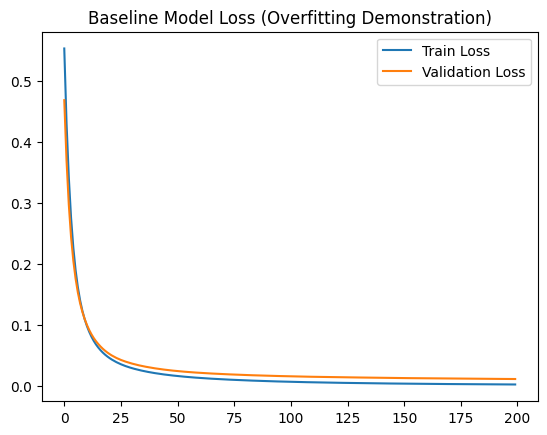

In [225]:
baseline_model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(15,)),          # 30 breast-cancer features
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid"),  # binary output
    ], name="Baseline_Model")

baseline_model.compile(
     optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Recall(name="recall")],
)

baseline_model.summary()

history_baseline = baseline_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=8,
    verbose=0
)


plt.figure()
plt.plot(history_baseline.history['loss'])
plt.plot(history_baseline.history['val_loss'])
plt.title("Baseline Model Loss (Overfitting Demonstration)")
plt.legend(["Train Loss", "Validation Loss"])
plt.show()

## Task 3: The Clinical Solution (Engineered Model)
**Instructions:** Build a second model using regularisation techniques (e.g., L2, Dropout, LeakyReLU). Train it and plot the curves to demonstrate the reduction in overfitting.

Model: "Engineered_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_251 (Dense)               │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_73 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_61 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_252 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_74 (LeakyReLU)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_253 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6594 - loss: 0.6719 - recall: 0.8800 - val_accuracy: 0.7875 - val_loss: 0.7911 - val_recall: 0.8200
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8000 - loss: 0.5315 - recall: 0.9250 - val_accuracy: 0.8875 - val_loss: 0.6580 - val_recall: 0.8400
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8781 - loss: 0.4420 - recall: 0.9300 - val_accuracy: 0.9000 - val_loss: 0.5567 - val_recall: 0.8400
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9187 - loss: 0.3948 - recall: 0.9150 - val_accuracy: 0.9000 - val_loss: 0.4630 - val_recall: 0.8400
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9375 - loss: 0.3210 - recall: 0.9400 - val_accuracy: 0.9000 - val_loss: 0.3744 - val_recall: 0.8400
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9344 - loss: 0.2903 - recall: 0.9300 - val_accuracy: 0.9125 - val_loss: 0.3020 - val_recall: 0.8600
Epoch 7/1

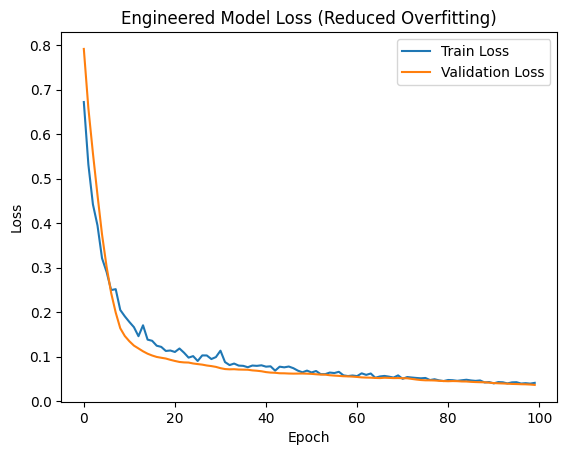

In [226]:
# =========================
# Task 3: Engineered Model
# =========================
l2 = tf.keras.regularizers.l2
engineered_model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(15,)),         
        tf.keras.layers.Dense(64, kernel_regularizer=l2(0.001)),
        tf.keras.layers.LeakyReLU(alpha=0.01),
        tf.keras.layers.Dropout(0.6),
        tf.keras.layers.Dense(32, kernel_regularizer=l2(0.001)),
        tf.keras.layers.LeakyReLU(alpha=0.01),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ], name="Engineered_Model")

engineered_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Recall(name="recall")],
)
engineered_model.summary()

history_engineered = engineered_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

# Plot loss curves
plt.figure()
plt.plot(history_engineered.history['loss'])
plt.plot(history_engineered.history['val_loss'])
plt.title("Engineered Model Loss (Reduced Overfitting)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train Loss", "Validation Loss"])
plt.show()

## Task 4: Evaluation & Mathematical Justification
**Instructions:**
1. Render the confusion matrices for both models.
2. Print the final validation Recall for both models.
3. Answer the justification question below.

In [227]:
# Predictions
baseline_probs = baseline_model.predict(X_val_scaled)
baseline_preds = (baseline_probs > 0.5).astype(int).flatten()

engineered_probs = engineered_model.predict(X_val_scaled)
engineered_preds = (engineered_probs > 0.5).astype(int).flatten()

# Confusion Matrices
baseline_cm = confusion_matrix(y_val, baseline_preds)
engineered_cm = confusion_matrix(y_val, engineered_preds)

print("Baseline Confusion Matrix:")
print(baseline_cm)

print("\nEngineered Confusion Matrix:")
print(engineered_cm)

# Final Validation Recall
baseline_recall = baseline_model.evaluate(X_val_scaled, y_val, verbose=0)[1]
engineered_recall = engineered_model.evaluate(X_val_scaled, y_val, verbose=0)[1]

print("\nFinal Validation Recall:")
print(f"Baseline Model Recall: {baseline_recall:.4f}")
print(f"Engineered Model Recall: {engineered_recall:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Baseline Confusion Matrix:
[[30  0]
 [ 1 49]]

Engineered Confusion Matrix:
[[30  0]
 [ 0 50]]

Final Validation Recall:
Baseline Model Recall: 0.9875
Engineered Model Recall: 1.0000


### Mathematical Justification
**Final Parameter Count of Engineered Model:** 3,137

**Explanation:** The engineered model's 3,137 parameters (approximately 20× the training set size) combined with L2 regularization (λ=0.001) penalizing large weights, 60% dropout forcing redundant representations, and LeakyReLU preventing dead neurons create a constrained optimization landscape that mathematically prevents the model from memorizing individual patient data by enforcing weight sparsity and requiring the network to learn generalizable patterns rather than fitting noise in the limited 160-sample training set.